# Approximating a Diagonal via Decision Trees

Whenever a node splits during the training of a Decision Tree, it divides the available data at that node into two halves — left and right. This is analogous to drawing a line **parallel to one of the axes** at each step, slicing the feature space into axis-aligned rectangles.

But what happens when the data cannot be separated by such lines? What if the true decision boundary is a diagonal — something no single axis-aligned cut can capture?

It turns out that Decision Trees can approximate even diagonal boundaries, given enough depth. By making finer and finer axis-aligned cuts, the tree builds up a **staircase-shaped boundary** that traces the diagonal more and more closely as the number of splits grows.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap

Tree trained! Actual number of leaf nodes used: 239


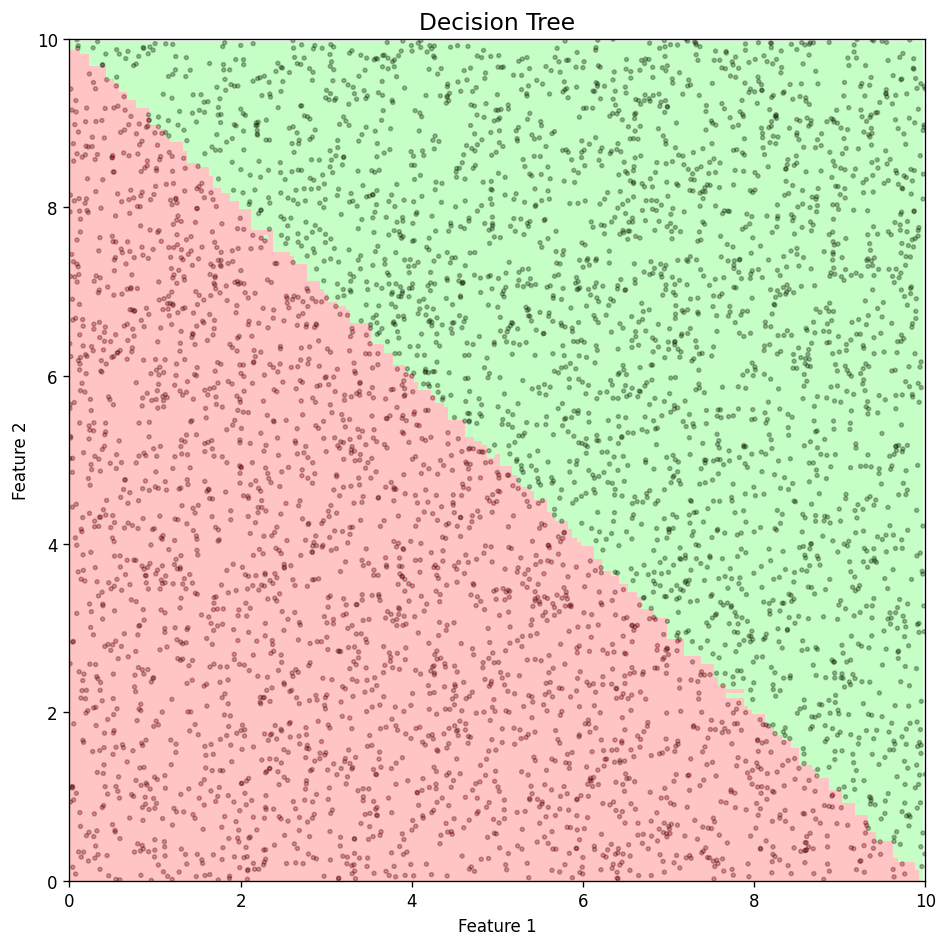

In [14]:
# Generate a MASSIVE dataset
n_points = 50000
X = np.random.rand(n_points, 2) * 10

# Perfect diagonal condition: x1 + x2 = 10
y = (X[:, 0] + X[:, 1] > 10).astype(int)

# Train a Decision Tree
clf = DecisionTreeClassifier(max_leaf_nodes=100000)
clf.fit(X, y)

print(f"Tree trained! Actual number of leaf nodes used: {clf.get_n_leaves()}")

plt.figure(figsize=(8, 8), dpi=120)
cmap_light = ListedColormap(["#FFC4C4", "#C6FFC6"])

xx_macro, yy_macro = np.meshgrid(np.arange(0, 10, 0.05), np.arange(0, 10, 0.05))
Z_macro = clf.predict(np.c_[xx_macro.ravel(), yy_macro.ravel()]).reshape(xx_macro.shape)

plt.pcolormesh(xx_macro, yy_macro, Z_macro, cmap=cmap_light)

plt.scatter(X[:5000, 0], X[:5000, 1], c=y[:5000], edgecolor='k', s=5,
            cmap=ListedColormap(["#FF0000", "#154B00"]), alpha=0.3)

plt.title("Decision Tree", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.xlim(0, 10)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()